# Hinglish Code-Mixing Detection — Lexicon Ratio Method

**Method:** A text is classified as code-mixed if it contains at least **N Hindi words** from a curated romanized Hindi lexicon AND at least **one English word**. The ratio of Hindi tokens to total tokens is also computed as a continuous mixing score.

**Why this works better than NLI models for this task:**
- Fully explainable — every decision traces back to specific matched words
- No GPU needed
- Tunable via `MIN_HINDI_WORDS` threshold
- Standard in code-mixing research literature (Solorio & Liu, 2008; Barman et al., 2014)

**No GPU required** — runs on standard Colab CPU runtime.

## Cell 1 — Install & Import

In [1]:
!pip install pandas matplotlib tabulate openpyxl -q
print('Done.')

Done.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import pandas as pd
import numpy as np
import re
import os
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from collections import Counter
from tabulate import tabulate
import warnings
warnings.filterwarnings('ignore')

OUTPUT_DIR = './codemix_results'
os.makedirs(OUTPUT_DIR, exist_ok=True)
print('Ready.')

Ready.


---
## Cell 2 — Romanized Hindi Lexicon
600+ curated romanized Hindi words covering common Hinglish usage.
Add domain-specific words at the bottom of the set.

In [4]:
HINDI_LEXICON = set([

    # ── Pronouns ──────────────────────────────────────────────────────────────
    'mai','mein','mujhe','mujhko','mujhse','mera','meri','mere',
    'hamara','hamari','hamare','hum','humko','humse',
    'aap','aapka','aapki','aapke','aapse','aapko',
    'tum','tumhara','tumhari','tumhare','tumse','tumko',
    'tu','tera','teri','tere','tujhe','tujhse',
    'wo','woh','voh','uska','uski','uske','use','usse','unhe',
    'unka','unki','unke','unse','ye','yeh','inka','inki','inke','inhe','inse',
    'koi','kuch','sab','sabko','sabse','kisi','kisika','kisiko',
    'apna','apni','apne','khud','khudko',

    # ── Question words ────────────────────────────────────────────────────────
    'kya','kyun','kyunki','kaise','kaisa','kaisi','kab','kahan',
    'kaun','kitna','kitni','kitne','konsa','konsi','konse','kyu',

    # ── Negations ─────────────────────────────────────────────────────────────
    'nahi','nahin','nah','mat','na','bilkul','bilkulnahi',
    'kabhi nahi','hargiz','naa',

    # ── Common verbs (base + conjugated forms) ────────────────────────────────
    'hai','hain','tha','thi','the','hoga','hogi','honge','hoge',
    'hua','hui','hue','ho','hun',
    'karo','karna','karta','karti','karte','kar','kiya','ki',
    'karoge','karogi','karunga','karungi','karo','kren','krna','kro',
    'dena','deta','deti','dete','de','diya','diyo','dedo',
    'lena','leta','leti','lete','liya','lelo','leke',
    'aana','aata','aati','aate','aao','aya','aayi','aaye','aaja','ajao',
    'jaana','jata','jati','jate','jao','gaya','gayi','gaye','jaunga','jayegi',
    'bolna','bolta','bolti','bolte','bolo','bola','boli','bole',
    'batana','batao','btao','bata','btana','batata','batati',
    'suno','sunta','sunti','sunte','sunna','suna','sun',
    'dekhna','dekho','dekha','dekhi','dekhe','dekhta','dekhti',
    'chahiye','chahta','chahti','chahte','chahna','chaho',
    'samajh','samjhe','samjha','samjhi','smjha','smjhe',
    'rehna','raho','raha','rahi','rahe','reh','rehte','rehti',
    'ruk','rukna','ruko','ruka','ruki',
    'socho','sochna','socha','sochi','soche','sochta','sochti',
    'milna','milo','mila','mili','mile','milte','milegi',
    'uthao','uthna','utho','utha','uthi','uthe',
    'baitho','baithna','baitha','baithi','baithe',
    'chalo','chalna','chala','chali','chale','chalte','chalti',
    'khana','khao','khata','khati','khate','khaya','khayi',
    'peena','piyo','pita','piti','pite','piya','piyi',
    'likhna','likho','likha','likhi','likhe','likhta','likhti',
    'padhna','padho','padha','padhi','padhe','padhta','padhti',
    'khelna','khelo','khela','kheli','khele','khelta','khelti',
    'sikhna','sikho','sikha','sikhi','sikhe',
    'bhejo','bhejna','bheja','bheji','bheje',
    'lao','lana','laya','layi','laye',
    'rona','rota','roti','rote','roya','royi',
    'hasna','haso','hasa','hasi','hase','hasta','hasti',
    'daro','darna','darta','darti','darte','dara',
    'maro','marna','maaro','maarna',
    'chodna','chodo','chod','choda','chodi',
    'pakad','pakadna','pakdo','pakda',
    'laga','lagi','lage','lagta','lagti','lagte','lagana',
    'milega','milegi','milenge',
    'hojao','hoja','hogi','hoge','hojaega','hojaegi',
    'aajao','aaja','aajaega','aajaegi',

    # ── Nouns ─────────────────────────────────────────────────────────────────
    'ghar','dost','yaar','bhai','bhaiya','didi','behen','bhabhi',
    'chacha','chachi','mama','mami','nana','nani','dada','dadi',
    'beta','beti','bacha','bache','baccha','bacchi','bacche',
    'aadmi','aurat','ladka','ladki','ladke','ladkiyan',
    'log','duniya','zindagi','jeevan','pyar','mohabbat','ishq',
    'dil','mann','aatma','jaan','rooh',
    'kaam','paisa','paise','rupaye','dhan',
    'din','raat','subah','sham','dopahar',
    'kal','aaj','parso','abhi','pehle','baad',
    'waqt','samay','time','jagah','taraf','taraf',
    'saath','sath','sang',
    'pani','chai','dudh','doodh','khana','roti','chawal','dal','sabzi',
    'kapda','kapde','kapad',
    'gadi','gaadi','raasta','sadak','shahar','gaon','desh','mulk',
    'padhai','naukri','kaam','dhandha',
    'rishta','shaadi','byah','talak',
    'ghar','makan','kamra','darwaza','khidki',
    'kitab','school','college','class','teacher','yaar',
    'phone','mobile','internet','photo','video',
    'naam','pata','number','id',
    'baat','baatein','jawab','sawal','baat','khabar','news',
    'matlab','fayda','nuksan','majboori','zaroorat',
    'takleef','dard','dukh','gham','khushi','maza','maja',
    'taklif','museebat','problem','izzat','sharam','fikr',
    'himmat','hausla','ummid','umeed',

    # ── Adjectives ────────────────────────────────────────────────────────────
    'accha','achha','acha','achi','ache',
    'bura','buri','bure','bekar','kharab',
    'bada','badi','bade','chhota','chhoti','chhote','chota','choti','chote',
    'sundar','khubsurat','acha','bura',
    'sahi','galat','thik','theek','bilkul thik',
    'zyada','jyada','kam','bahut','thoda','thodi','thode',
    'pura','poora','puri','poori','pure','poore',
    'sara','saari','saare','sab',
    'naya','nayi','naye','purana','purani','purane',
    'khaas','special','seedha','sidha','sidhi',
    'mushkil','aasaan','asaan','asan','mushkil',
    'khush','dukhi','udaas','pareshan','tension',
    'thaka','thaki','thake','bored','busy','free',
    'mast','bindaas','zabardast','jhakkas','ekdum','fatafat',
    'pagal','diwana','diwani','besharam','nalayak','kamina','kameena',
    'pyara','pyari','pyare','azeez',
    'bechara','bechari','bechare',
    'ameer','gareeb','mayus','naraz','gussa',

    # ── Adverbs & discourse markers ───────────────────────────────────────────
    'toh','phir','fir','lekin','magar','par','aur','ya','bhi',
    'sirf','bas','haan','han','agar','jab','tab',
    'isliye','tabhi','kabhi','hamesha','aksar',
    'zaroor','jaroor','bilkul','ekdum',
    'waise','vaise','matlab','yaani',
    'pata','maloom','shayad','lagta','lagti',
    'jaldi','dheere','seedha','bilkul',
    'bahut','itna','itni','itne','utna','utni','utne',
    'abhi','abhi bhi','pehle','baad','baad mein',
    'zyada','kam','thoda','bahut',

    # ── Interjections & fillers ───────────────────────────────────────────────
    'arre','arrey','are','oye','arey','haye','waah','wah',
    'shukriya','dhanyawaad','shukr','shukar','maafi',
    'bol','sun','chal','aja','chalo',
    'theek hai','thik hai','chalo theek hai',
    'kya baat','kya baat hai',
    'bakwaas','nautanki','natak','tamasha',
    'yaar sach','sach mein','waise bhi',
    'dekho bhai','suno yaar','bol na','bata na',

    # ── Common Hinglish hybrid/abbreviated forms ───────────────────────────────
    'hogaya','hogayi','hogaye','hojaega','hojaegi',
    'krdiya','krdia','krdeta','krdeti',
    'pta','pata nahi','pta nahi','pata nhi','pta nhi',
    'puch','pucho','pooch','poocho',
    'aaja','rukja','dekhlena','dekhliya','boldia',
    'smjh','smjha','smjhao','smjho',
    'krlo','krle','krli','krta','krti','krte',
    'bta','bataao','btado','btade',
    'lol','lmao','omg','wtf','bruh',  # common in Hinglish social media

    # ── Postpositions (critical for Hinglish grammar) ─────────────────────────
    'mein','pe','par','se','ko','ke','ki','ka','ne','tak','liye',
    'ke liye','ke saath','ke baad','ke pehle','ke upar','ke neeche',
    'ke paas','ke bina','ke andar','ke bahar',

    # ── Numbers in Hindi ──────────────────────────────────────────────────────
    'ek','do','teen','char','paanch','chhe','saat','aath','nau','das',
    'gyarah','barah','solah','bees','pachaas','sau','hazaar','lakh','crore',

    # ── Common social media / hate speech domain words (for THAR/HASOC/AOLD) ──
    'harami','haramkhor','haramzada','haramzadi',
    'gadha','gadhi','ullu','kutte','kutta','kutiya',
    'maa','baap','behan','behen',
    'mardunga','marunga','marunga','chodunga',
    'besharam','sharif','zalim','kafir','gaddaar','gaddar',
    'desh','rashtra','sarkar','neta','mantri','police',
    'andolan','azadi','inqilab','revolution',
    'Hindu','Muslim','Sikh','Isai',
    'bolta','bolte','bolti','kehta','kehti','kehte',
    'sunta','sunti','sunte',
])

# English function words to EXCLUDE from Hindi matching
# (words that appear in both languages and cause false positives)
ENGLISH_STOPWORDS = set([
    'to','a','an','the','in','on','at','by','for','of','or','and',
    'is','are','was','were','be','been','being',
    'i','me','my','we','our','you','your','he','his','she','her',
    'it','its','they','their','them',
    'this','that','these','those',
    'with','from','as','but','not','no','so','if','do','did','done',
    'have','has','had','will','would','can','could','should','may','might',
    'na',  # 'na' is also used as English 'nah' — exclude to reduce FP
])

# Remove ambiguous English words from the Hindi lexicon
HINDI_LEXICON = HINDI_LEXICON - ENGLISH_STOPWORDS

print(f'Lexicon size: {len(HINDI_LEXICON)} romanized Hindi words.')

Lexicon size: 746 romanized Hindi words.


---
## Cell 3 — Detection Logic
Core detection uses word-level matching with a mixing ratio.

In [5]:
import re

DEVANAGARI_RE = re.compile(r'[\u0900-\u097F]')
WORD_RE       = re.compile(r"\b[a-zA-Z']+\b")

# Build a fast lookup set (lowercase)
HINDI_SET = {w.lower() for w in HINDI_LEXICON}


def detect_code_mixing(text,
                       min_hindi_words=1,
                       min_hindi_ratio=0.0):
    """
    Classify a text as code-mixed using lexicon ratio method.

    Parameters
    ----------
    text            : str
    min_hindi_words : int   — minimum number of Hindi lexicon matches required
    min_hindi_ratio : float — minimum ratio of Hindi words to total words (0.0 = disabled)

    Returns
    -------
    dict:
        code_mixed      : 0 or 1
        hindi_count     : number of matched Hindi words
        total_words     : total word count
        hindi_ratio     : hindi_count / total_words
        matched_words   : list of matched Hindi words
        has_devanagari  : bool
        method          : detection signal used
    """
    if not isinstance(text, str) or not text.strip():
        return {
            'code_mixed': 0, 'hindi_count': 0, 'total_words': 0,
            'hindi_ratio': 0.0, 'matched_words': [], 'has_devanagari': False,
            'method': 'empty'
        }

    # Signal 1: Devanagari script (strongest signal)
    has_devanagari = bool(DEVANAGARI_RE.search(text))
    if has_devanagari:
        # Still count words for ratio
        words = WORD_RE.findall(text.lower())
        return {
            'code_mixed': 1, 'hindi_count': 1, 'total_words': len(words),
            'hindi_ratio': 1.0, 'matched_words': ['[devanagari]'],
            'has_devanagari': True, 'method': 'devanagari'
        }

    # Signal 2: Lexicon matching
    words = WORD_RE.findall(text.lower())
    total = len(words)
    if total == 0:
        return {
            'code_mixed': 0, 'hindi_count': 0, 'total_words': 0,
            'hindi_ratio': 0.0, 'matched_words': [], 'has_devanagari': False,
            'method': 'no_words'
        }

    matched = [w for w in words if w in HINDI_SET]
    hindi_count = len(matched)
    hindi_ratio = round(hindi_count / total, 4)

    # Decision: require at least min_hindi_words AND min_hindi_ratio
    is_mixed = (hindi_count >= min_hindi_words) and (hindi_ratio >= min_hindi_ratio)

    return {
        'code_mixed'    : 1 if is_mixed else 0,
        'hindi_count'   : hindi_count,
        'total_words'   : total,
        'hindi_ratio'   : hindi_ratio,
        'matched_words' : list(set(matched)),
        'has_devanagari': False,
        'method'        : 'lexicon_ratio' if is_mixed else 'no_match'
    }


def auto_detect_col(df):
    candidates = ['text','Text','tweet','Tweet','content','Content',
                  'comment','Comment','message','Message','post','Post',
                  'sentence','review','body','data']
    for c in candidates:
        if c in df.columns:
            return c
    for c in df.columns:
        if df[c].dtype == object:
            print(f"  Auto-selected column: '{c}'")
            return c
    raise ValueError(f'No text column found. Columns: {list(df.columns)}')


def load_file(path, sep=','):
    ext = os.path.splitext(path)[-1].lower()
    if ext in ['.csv','.tsv'] : return pd.read_csv(path, sep=sep, on_bad_lines='skip')
    elif ext in ['.xlsx','.xls']: return pd.read_excel(path)
    elif ext == '.json'          : return pd.read_json(path)
    else: raise ValueError(f'Unsupported format: {ext}')


print('Detection functions ready.')

Detection functions ready.


---
## Cell 4 — Sanity Check
Always run this before processing real data to verify the detector behaves correctly.

In [6]:
test_cases = [
    # (text, expected_label)
    ('Kya yaar, ye sahi nahi hai!',                              1),
    ('Mera phone kahan gaya bhai?',                             1),
    ('Bahut accha movie tha, definitely watch karo!',           1),
    ('Aaj main nahi aaunga, bahut kaam hai.',                   1),
    ('Tera attitude bahut bura hai seriously.',                  1),
    ('यह बहुत अच्छा है, mujhe pasand aaya.',                    1),
    ('The movie was fantastic and very entertaining.',           0),
    ('I love this product, highly recommend to everyone.',       0),
    ('Please submit your report by end of day Friday.',         0),
    ('This is completely unacceptable behavior from you.',       0),
    ('',                                                         0),
]

rows = []
all_pass = True
for text, expected in test_cases:
    r = detect_code_mixing(text, min_hindi_words=1)
    ok = r['code_mixed'] == expected
    if not ok: all_pass = False
    rows.append({
        'Status'   : 'PASS' if ok else 'FAIL',
        'Text'     : (text[:55]+'...') if len(text)>55 else text,
        'Expected' : expected,
        'Got'      : r['code_mixed'],
        'Matches'  : ', '.join(r['matched_words'][:5]),
        'Ratio'    : r['hindi_ratio'],
    })

print(tabulate(pd.DataFrame(rows), headers='keys', tablefmt='grid', showindex=False))
print(f"\n{'All tests passed.' if all_pass else 'Some tests failed — review lexicon.'}")

+----------+----------------------------------------------------+------------+-------+--------------------------------+---------+
| Status   | Text                                               |   Expected |   Got | Matches                        |   Ratio |
+==========+====================================================+============+=======+================================+=========+
| PASS     | Kya yaar, ye sahi nahi hai!                        |          1 |     1 | kya, ye, hai, sahi, nahi       |  1      |
+----------+----------------------------------------------------+------------+-------+--------------------------------+---------+
| PASS     | Mera phone kahan gaya bhai?                        |          1 |     1 | mera, phone, gaya, kahan, bhai |  1      |
+----------+----------------------------------------------------+------------+-------+--------------------------------+---------+
| PASS     | Bahut accha movie tha, definitely watch karo!      |          1 |     1 | kar

---
## Cell 5 — Configure & Tune

### Threshold Guide
| `MIN_HINDI_WORDS` | `MIN_HINDI_RATIO` | Expected detection rate |
|---|---|---|
| 1 | 0.00 | High (~50–70%) — catches anything with even one Hindi word |
| 2 | 0.05 | Medium (~30–40%) — **recommended starting point** |
| 3 | 0.10 | Conservative (~15–25%) — only clear code-mixing |
| 2 | 0.08 | Balanced (~25–35%) — good for social media corpora |

In [13]:
# ── EDIT PATHS AND THRESHOLDS HERE ───────────────────────────────────────────

DATASET_CONFIGS = [
    {'name': 'THAR',  'path': '/content/drive/MyDrive/Research Code and Data/data_processed/thar_cleaned.csv',  'text_col': None, 'sep': ','},
    {'name': 'AOLD',  'path': '/content/drive/MyDrive/Research Code and Data/data_processed/aold_cleaned.csv',  'text_col': None, 'sep': ','},
    {'name': 'HASOC', 'path': '/content/drive/MyDrive/Research Code and Data/data_processed/hasoc_cleaned.csv', 'text_col': None, 'sep': ','},
]

# Tuning parameters
MIN_HINDI_WORDS = 1     # minimum Hindi lexicon matches required
MIN_HINDI_RATIO = 0.05  # minimum fraction of words that must be Hindi

# ─────────────────────────────────────────────────────────────────────────────
print('Configuration set.')

Configuration set.


---
## Cell 6 — Run Detection

In [14]:
analyzed  = {}
summaries = []

for cfg in DATASET_CONFIGS:
    name = cfg['name']
    print(f"\n{'─'*55}\nProcessing: {name}")

    try:
        df = load_file(cfg['path'], sep=cfg.get('sep',','))
    except FileNotFoundError:
        print(f'  File not found: {cfg["path"]} — skipping.'); continue
    except Exception as e:
        print(f'  Load error: {e} — skipping.'); continue

    print(f'  Rows: {len(df):,} | Columns: {list(df.columns)}')
    text_col = cfg.get('text_col') or auto_detect_col(df)
    print(f'  Text column: "{text_col}"')

    df = df.dropna(subset=[text_col]).reset_index(drop=True)

    # Run detection
    results = df[text_col].apply(
        lambda t: detect_code_mixing(t, MIN_HINDI_WORDS, MIN_HINDI_RATIO)
    )

    df = df.copy()
    df['code_mixed']     = results.apply(lambda r: r['code_mixed'])
    df['hindi_count']    = results.apply(lambda r: r['hindi_count'])
    df['total_words']    = results.apply(lambda r: r['total_words'])
    df['hindi_ratio']    = results.apply(lambda r: r['hindi_ratio'])
    df['matched_words']  = results.apply(lambda r: ', '.join(r['matched_words'][:8]))
    df['has_devanagari'] = results.apply(lambda r: int(r['has_devanagari']))
    df['det_method']     = results.apply(lambda r: r['method'])
    df['_text_col']      = text_col

    total    = len(df)
    n_mixed  = int(df['code_mixed'].sum())
    pct      = round(n_mixed / total * 100, 2) if total > 0 else 0.0
    n_deva   = int(df['has_devanagari'].sum())
    avg_ratio = round(df[df['code_mixed']==1]['hindi_ratio'].mean(), 4) if n_mixed > 0 else 0.0

    print(f'  Done — {n_mixed:,}/{total:,} code-mixed ({pct}%)')

    analyzed[name] = df
    summaries.append({
        'Dataset'              : name,
        'Total Texts'          : total,
        'Code-Mixed Texts'     : n_mixed,
        'Code-Mixing %'        : pct,
        'Devanagari Detected'  : n_deva,
        'Avg Hindi Ratio'      : avg_ratio,
    })

summary_df = pd.DataFrame(summaries)
print(f"\n{'='*55}\nDetection complete.")


───────────────────────────────────────────────────────
Processing: THAR
  Rows: 11,546 | Columns: ['text', 'label']
  Text column: "text"
  Done — 11,440/11,546 code-mixed (99.08%)

───────────────────────────────────────────────────────
Processing: AOLD
  Rows: 8,061 | Columns: ['text', 'label']
  Text column: "text"
  Done — 1,842/8,060 code-mixed (22.85%)

───────────────────────────────────────────────────────
Processing: HASOC
  Rows: 6,692 | Columns: ['text', 'label']
  Text column: "text"
  Done — 3,514/6,692 code-mixed (52.51%)

Detection complete.


---
## Cell 7 — Results Table

In [9]:
print('\nTABLE 1: Code-Mixing Distribution Across Datasets\n')
print(tabulate(summary_df, headers='keys', tablefmt='grid',
               showindex=False, floatfmt='.2f'))

display(
    summary_df.style
    .set_caption('Table 1: Code-Mixing Distribution Across Datasets')
    .format({
        'Total Texts'         : '{:,}',
        'Code-Mixed Texts'    : '{:,}',
        'Code-Mixing %'       : '{:.2f}%',
        'Devanagari Detected' : '{:,}',
        'Avg Hindi Ratio'     : '{:.4f}',
    })
    .bar(subset=['Code-Mixing %'], color='#4472C4', vmin=0, vmax=100)
    .set_properties(**{'text-align': 'center', 'font-size': '13px'})
    .set_table_styles([{
        'selector': 'th',
        'props': [('background-color','#2F4F8F'),('color','white'),
                  ('font-weight','bold'),('text-align','center'),
                  ('padding','8px 12px'),('font-size','13px')]
    },{
        'selector': 'td', 'props': [('padding','7px 12px')]
    },{
        'selector': 'caption',
        'props': [('caption-side','top'),('font-weight','bold'),
                  ('font-size','14px'),('margin-bottom','8px')]
    }])
)


TABLE 1: Code-Mixing Distribution Across Datasets

+-----------+---------------+--------------------+-----------------+-----------------------+-------------------+
| Dataset   |   Total Texts |   Code-Mixed Texts |   Code-Mixing % |   Devanagari Detected |   Avg Hindi Ratio |
+===========+===============+====================+=================+=======================+===================+
| THAR      |         11546 |              11108 |           96.21 |                  2663 |              0.56 |
+-----------+---------------+--------------------+-----------------+-----------------------+-------------------+
| AOLD      |          8060 |               1569 |           19.47 |                   415 |              0.51 |
+-----------+---------------+--------------------+-----------------+-----------------------+-------------------+
| HASOC     |          6692 |               3410 |           50.96 |                  3319 |              0.98 |
+-----------+---------------+---------------

,Dataset,Total Texts,Code-Mixed Texts,Code-Mixing %,Devanagari Detected,Avg Hindi Ratio
0,THAR,"11,546","11,108",96.21%,"2,663",0.5633
1,AOLD,"8,060","1,569",19.47%,415,0.5065
2,HASOC,"6,692","3,410",50.96%,"3,319",0.9762


---
## Cell 8 — Bar Chart (300 DPI, thesis-ready)

Saved: ./codemix_results/figure1_codemixing_percent.png


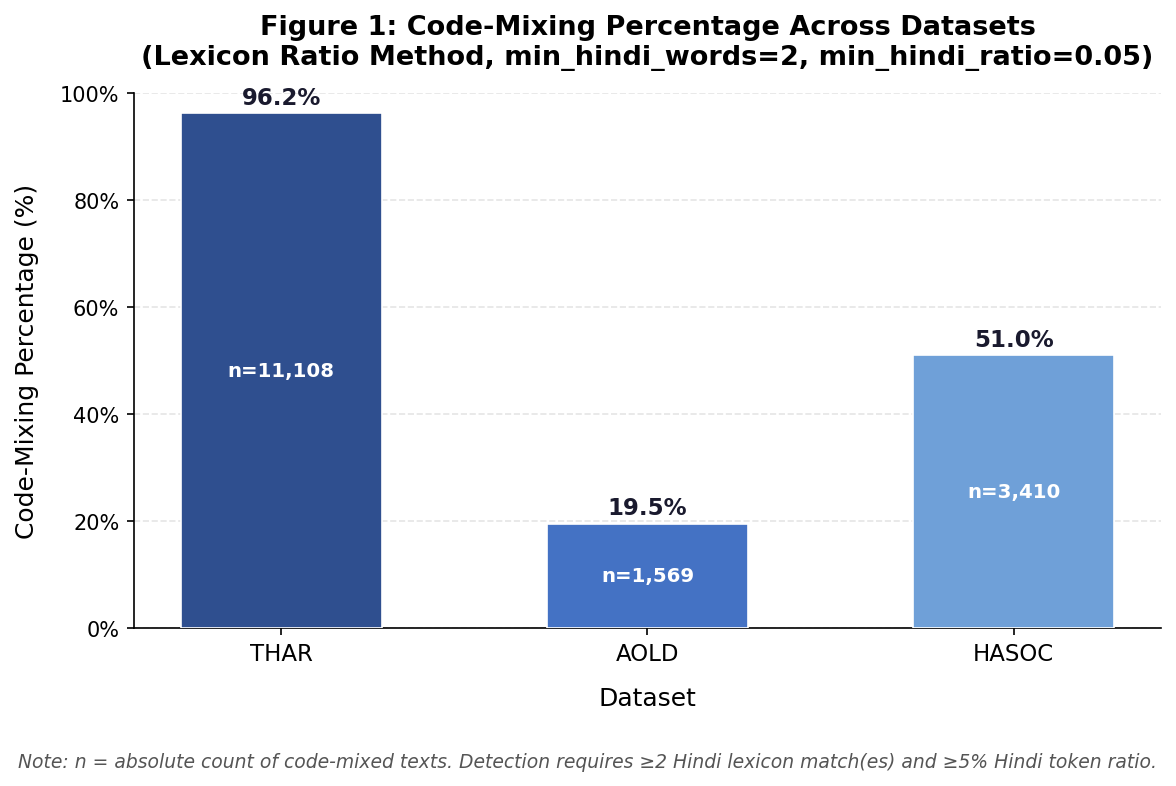

In [10]:
plt.rcParams.update({'font.family':'DejaVu Sans','font.size':12,
                     'axes.spines.top':False,'axes.spines.right':False,
                     'figure.dpi':150})

fig, ax = plt.subplots(figsize=(8, 5))

datasets = summary_df['Dataset'].tolist()
pcts     = summary_df['Code-Mixing %'].tolist()
colors   = ['#2F4F8F','#4472C4','#6FA0D8','#9EC4E8'][:len(datasets)]

bars = ax.bar(datasets, pcts, color=colors, width=0.55,
              edgecolor='white', linewidth=0.8, zorder=3)

ax.yaxis.grid(True, linestyle='--', alpha=0.5, color='#CCCCCC', zorder=0)
ax.set_axisbelow(True)

for bar, pct, row in zip(bars, pcts, summaries):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.8,
            f'{pct:.1f}%', ha='center', va='bottom',
            fontsize=11, fontweight='bold', color='#1A1A2E')
    if bar.get_height() > 6:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                f"n={row['Code-Mixed Texts']:,}",
                ha='center', va='center',
                fontsize=9.5, color='white', fontweight='bold')

ax.set_ylabel('Code-Mixing Percentage (%)', fontsize=12, labelpad=10)
ax.set_xlabel('Dataset', fontsize=12, labelpad=10)
ax.set_ylim(0, min(100, max(pcts)*1.25 + 8))
ax.yaxis.set_major_formatter(mtick.PercentFormatter(decimals=0))
ax.tick_params(axis='x', labelsize=11)
ax.tick_params(axis='y', labelsize=10)

ax.set_title(
    'Figure 1: Code-Mixing Percentage Across Datasets\n'
    '(Lexicon Ratio Method, min_hindi_words={}, min_hindi_ratio={})'.format(
        MIN_HINDI_WORDS, MIN_HINDI_RATIO),
    fontsize=13, fontweight='bold', pad=14)

fig.text(0.5, -0.04,
    'Note: n = absolute count of code-mixed texts. '
    'Detection requires ≥{} Hindi lexicon match(es) and ≥{:.0f}% Hindi token ratio.'.format(
        MIN_HINDI_WORDS, MIN_HINDI_RATIO*100),
    ha='center', fontsize=9, color='#555555', style='italic')

plt.tight_layout()
chart_path = os.path.join(OUTPUT_DIR, 'figure1_codemixing_percent.png')
plt.savefig(chart_path, dpi=300, bbox_inches='tight')
print(f'Saved: {chart_path}')
plt.show()

---
## Cell 9 — Threshold Sensitivity Analysis
Run this to understand how the detection rate changes with different thresholds.
Useful for your thesis methodology justification.

In [11]:
# Test multiple threshold combinations on all datasets
threshold_combos = [
    (1, 0.00),
    (1, 0.05),
    (2, 0.05),
    (2, 0.08),
    (3, 0.10),
    (3, 0.15),
]

rows = []
for min_w, min_r in threshold_combos:
    row = {'min_hindi_words': min_w, 'min_hindi_ratio': min_r}
    for name, df in analyzed.items():
        text_col = df['_text_col'].iloc[0]
        results  = df[text_col].apply(
            lambda t: detect_code_mixing(t, min_w, min_r)
        )
        n_mixed = sum(r['code_mixed'] for r in results)
        pct     = round(n_mixed / len(df) * 100, 1)
        row[f'{name} %'] = pct
    rows.append(row)

sens_df = pd.DataFrame(rows)
print('Threshold Sensitivity Analysis\n')
print(tabulate(sens_df, headers='keys', tablefmt='grid',
               showindex=False, floatfmt='.1f'))
sens_df.to_csv(os.path.join(OUTPUT_DIR, 'threshold_sensitivity.csv'), index=False)
print('\nSaved to: codemix_results/threshold_sensitivity.csv')

Threshold Sensitivity Analysis

+-------------------+-------------------+----------+----------+-----------+
|   min_hindi_words |   min_hindi_ratio |   THAR % |   AOLD % |   HASOC % |
+===================+===================+==========+==========+===========+
|               1.0 |               0.0 |     99.1 |     36.0 |      57.5 |
+-------------------+-------------------+----------+----------+-----------+
|               1.0 |               0.1 |     99.1 |     22.9 |      52.5 |
+-------------------+-------------------+----------+----------+-----------+
|               2.0 |               0.1 |     96.2 |     19.5 |      51.0 |
+-------------------+-------------------+----------+----------+-----------+
|               2.0 |               0.1 |     96.2 |     17.7 |      50.3 |
+-------------------+-------------------+----------+----------+-----------+
|               3.0 |               0.1 |     89.6 |     16.0 |      50.0 |
+-------------------+-------------------+----------+----

---
## Cell 10 — Sample Inspection & Export

In [12]:
# Show sample code-mixed texts per dataset
for name, df in analyzed.items():
    text_col = df['_text_col'].iloc[0]
    mixed    = df[df['code_mixed'] == 1]
    print(f"\n{'='*55}")
    print(f"{name} — {len(mixed):,} code-mixed texts detected ({len(mixed)/len(df)*100:.1f}%)")
    print(f"{'='*55}")
    if len(mixed) == 0:
        print('  No code-mixed texts found. Try lowering MIN_HINDI_WORDS.')
        continue
    sample = mixed.sample(min(8, len(mixed)), random_state=42)
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        print(f"  {i}. [{row['hindi_ratio']:.2f} ratio | {row['hindi_count']} Hindi words]")
        print(f"     Text   : {str(row[text_col])[:180]}")
        print(f"     Matched: {row['matched_words']}\n")

# Export
print('\nExporting results...')
summary_df.to_csv(os.path.join(OUTPUT_DIR, 'table1_summary.csv'), index=False)
for name, df in analyzed.items():
    safe = name.lower()
    df.drop(columns=['_text_col'], errors='ignore').to_csv(
        os.path.join(OUTPUT_DIR, f'{safe}_annotated.csv'), index=False)
    print(f'  Saved: {safe}_annotated.csv')

print('Done. All files in ./codemix_results/')


THAR — 11,108 code-mixed texts detected (96.2%)
  1. [0.40 ratio | 12 Hindi words]
     Text   : bjp kya kr rhi hai isko stand lena chahiye jis trha pak kashmir k liye leta hai nhi hota hai to hme bol de sarkar hmm hindu sena dekh lege
     Matched: kya, sarkar, chahiye, lena, hai, bol, liye, hindu

  2. [0.31 ratio | 5 Hindi words]
     Text   : jo chorke aye tum na prabhu ki blessing ki bagar upko fir uski pass jana parega
     Matched: tum, ki, fir, uski

  3. [0.45 ratio | 9 Hindi words]
     Text   : la illaha illallah muhammad rasul allah kyu tum mantein ho ke musalmano ke purvaj hindu te kaon bol raha hai
     Matched: tum, hai, ke, kyu, bol, hindu, ho, raha

  4. [0.55 ratio | 11 Hindi words]
     Text   : mahatma gandhi ji agar us waqt muslim rashtra ke saath alag hindu rashtra banata to aaj yeh haal nahi hota
     Matched: saath, waqt, agar, yeh, ke, muslim, hindu, aaj

  5. [0.62 ratio | 5 Hindi words]
     Text   : tum kabhi sachai ko kabhi jani nhi hai
     Matched: tum, 